# 1. Define the Problem

In [2]:
# Recommending crops based on environmental and soil parameters.

In [38]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import joblib

# 2. Collect and Understand Data

In [41]:
# Dataset is Collected from Kaggle
# Link 

In [43]:
# Load the dataset
df = pd.read_csv("Crop_Recom_Dataset.csv")

In [45]:
# Display the first few rows
print("Dataset Overview:")
print(df.head())

Dataset Overview:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [47]:
# Basic statistics
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  


In [49]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [51]:
# Check dataset balance
print("\nClass Distribution:")
print(df['label'].value_counts())


Class Distribution:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


In [53]:
# 3. Data Preprocessing
# Define input and target
Input = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
Target = df[['label']]

In [55]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
# Scale input features
scaler = MinMaxScaler()
Input = scaler.fit_transform(Input)

In [57]:
# Encode target labels
Encoder = OneHotEncoder(sparse_output=False)
Output = Encoder.fit_transform(Target)

In [59]:
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(Input, Output, test_size=0.3, random_state=42)

In [61]:
# Print shapes for verification
print("\nTraining and Testing Data Shapes:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


Training and Testing Data Shapes:
x_train: (1540, 7), y_train: (1540, 22)
x_test: (660, 7), y_test: (660, 22)


# 4. Exploratory Data Analysis (EDA)

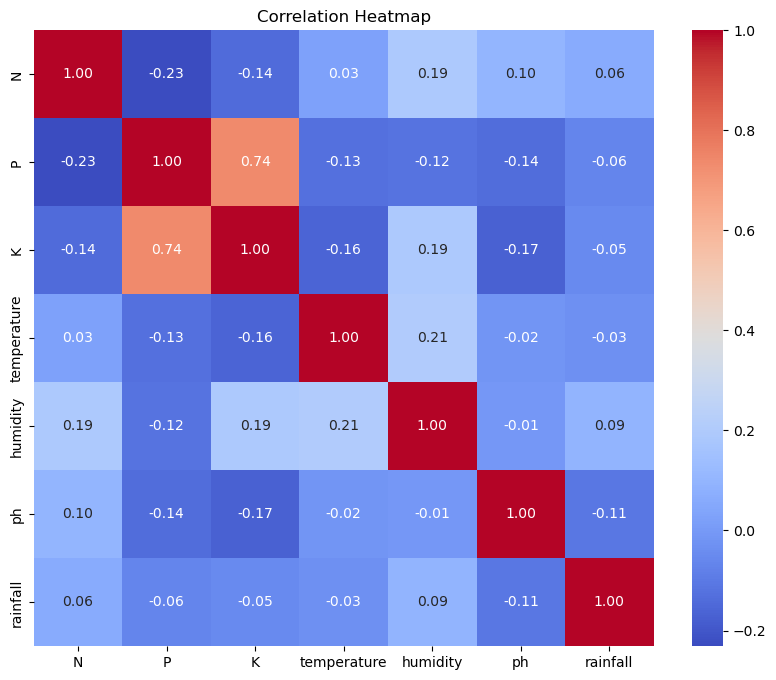

In [64]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

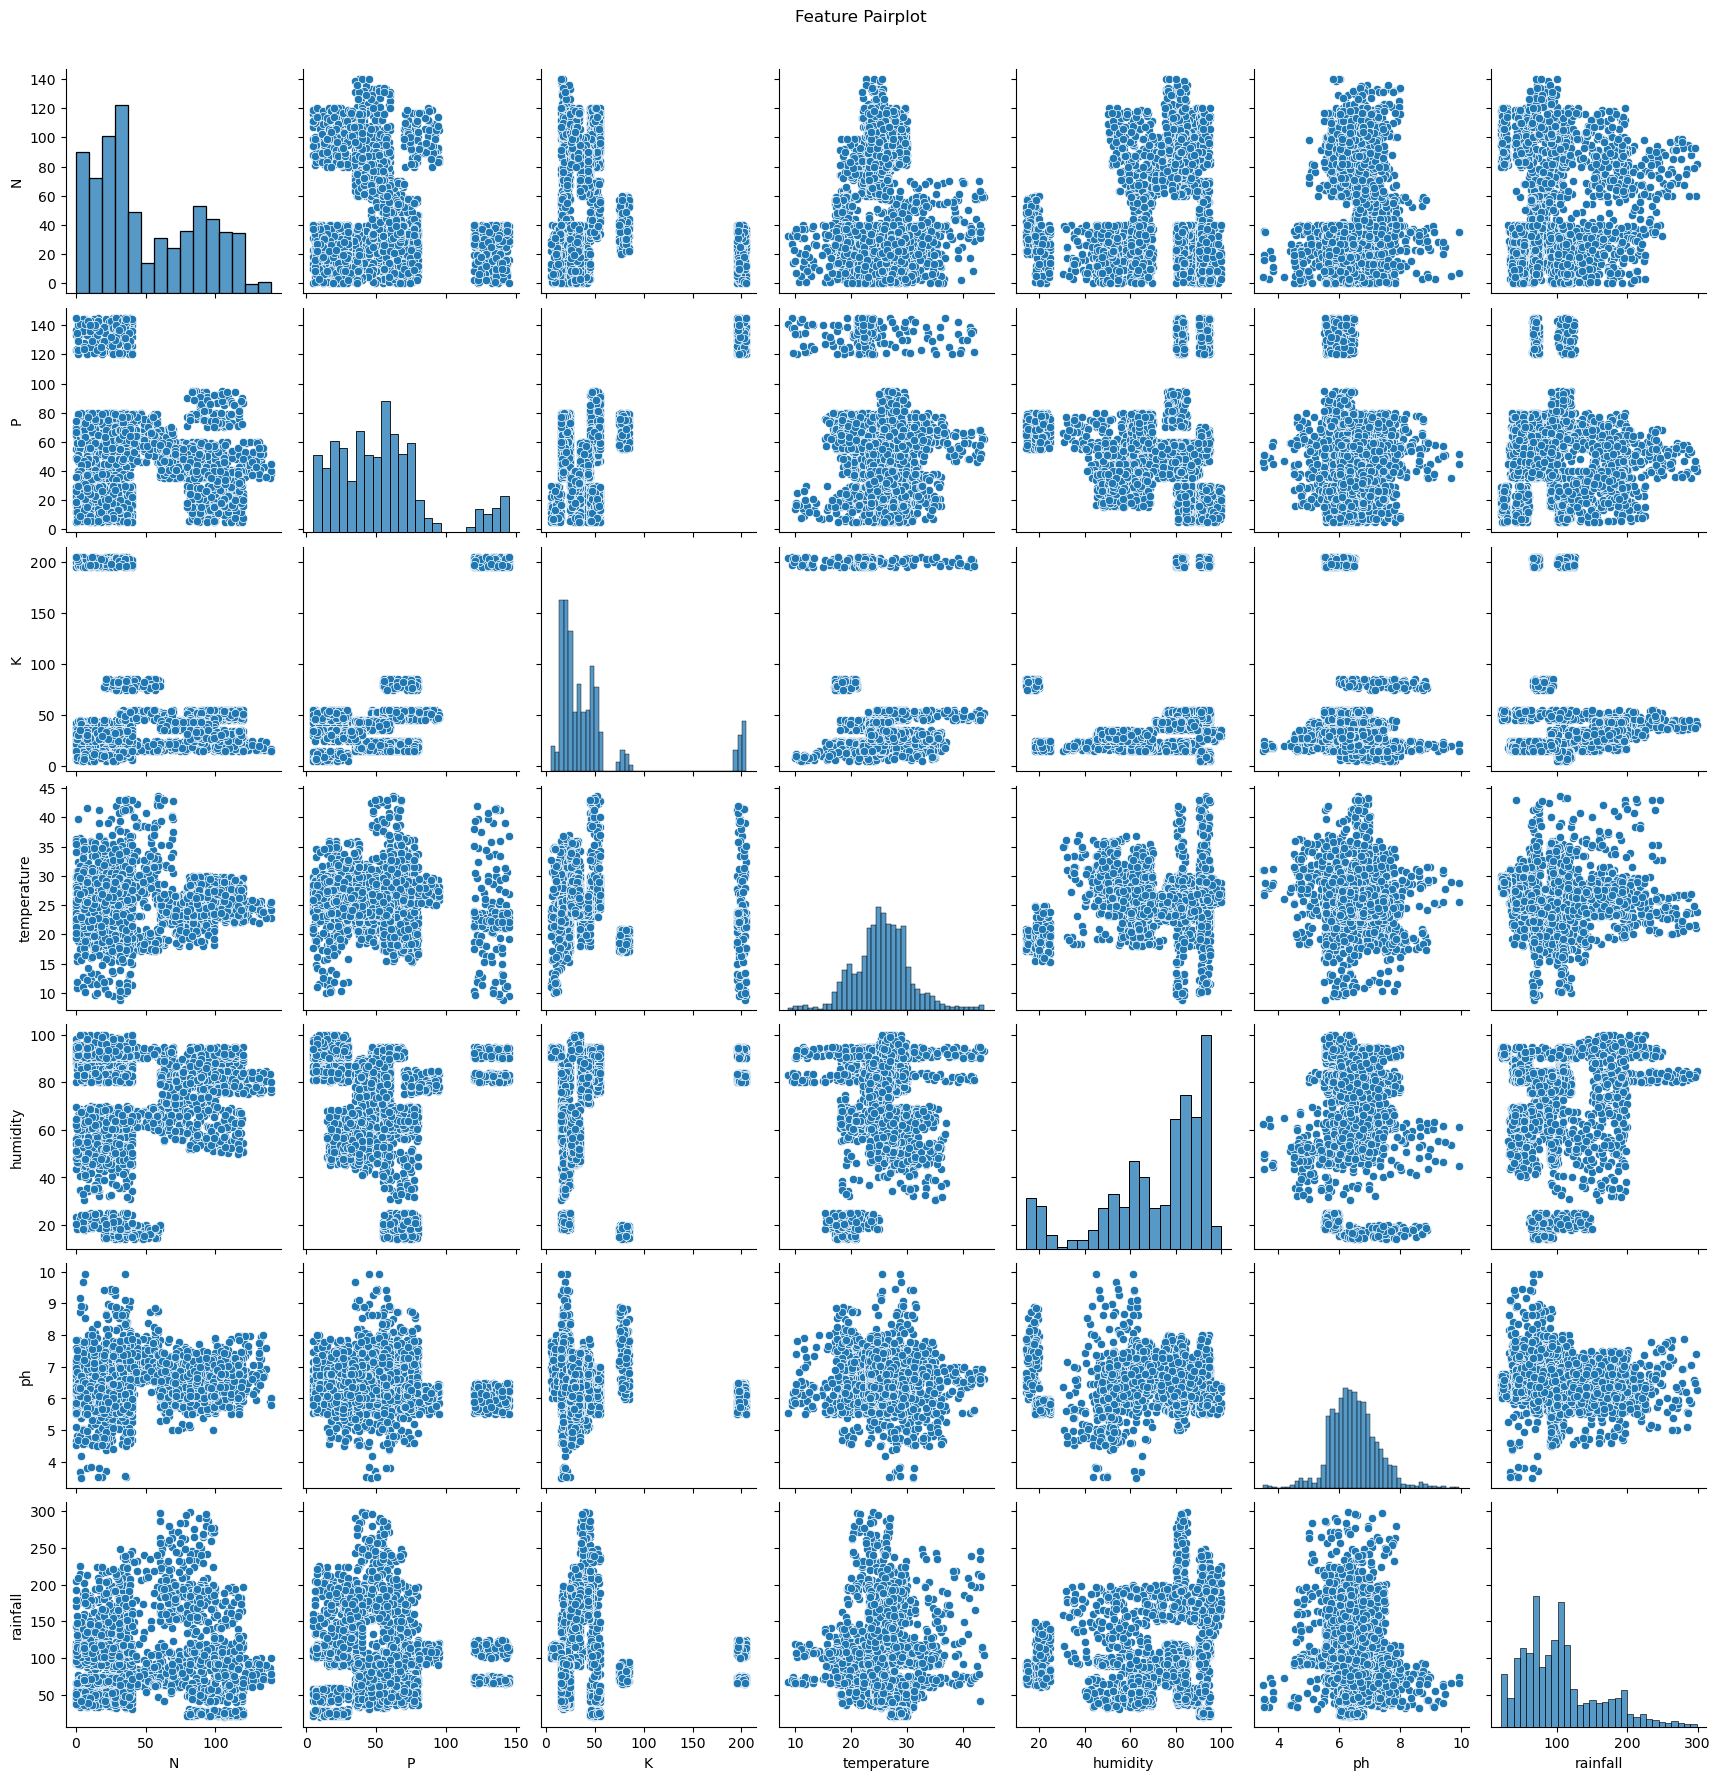

In [65]:
# Pairplot for input features
sns.pairplot(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']])
plt.suptitle("Feature Pairplot", y=1.02)
plt.show()

C:\Users\uppur\AppData\Local\Temp\ipykernel_19736\3295284670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


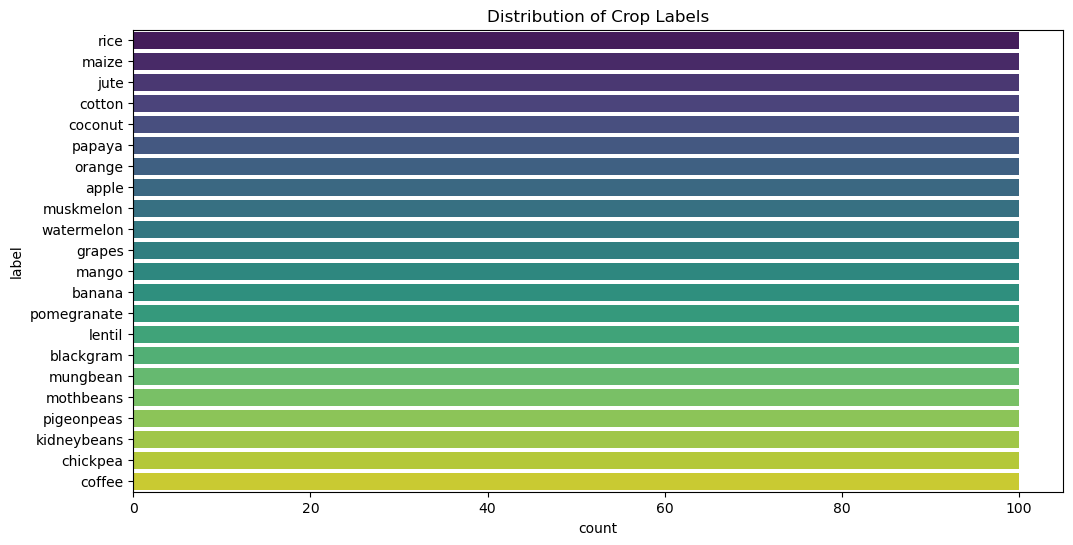

In [67]:
# Distribution of target classes
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title("Distribution of Crop Labels")
plt.show()

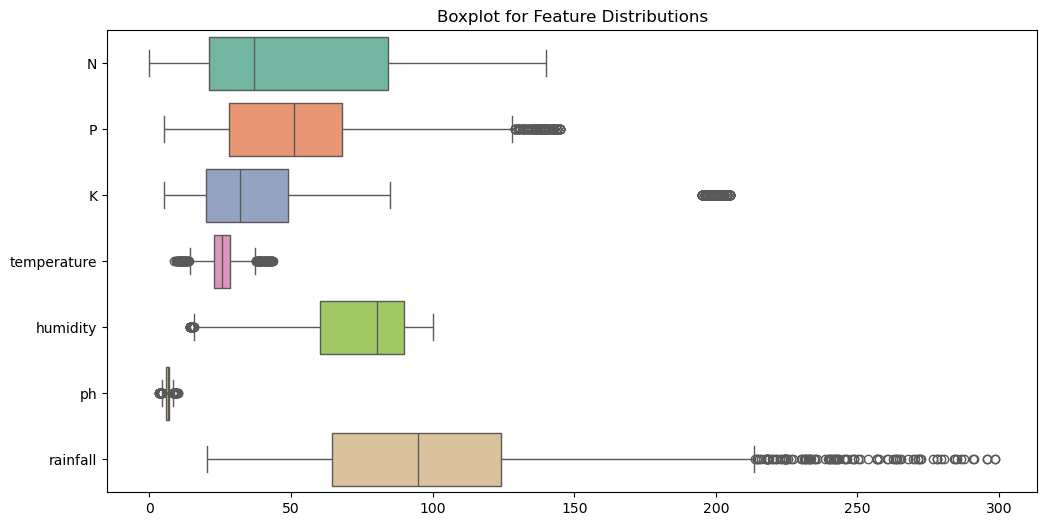

In [68]:
# Boxplot for feature distributions
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']], orient='h', palette='Set2')
plt.title("Boxplot for Feature Distributions")
plt.show()

# 5. Model Selection and Training

In [70]:
# Define the model
model = Sequential([
    Input(shape=(7,)),
    Dense(units=128, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=22, activation='softmax')
])


TypeError: 'numpy.ndarray' object is not callable

In [30]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 22)                  │             726 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,086 (47.21 KB)

 Trainable params: 12,086 (47.21 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train the model
history = model.fit(x_train, y_train, epochs=25, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.0862 - loss: 3.0293 - val_accuracy: 0.2015 - val_loss: 2.8225
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1910 - loss: 2.6721 - val_accuracy: 0.3030 - val_loss: 2.2283
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4027 - loss: 1.9857 - val_accuracy: 0.6530 - val_loss: 1.4764
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6929 - loss: 1.3124 - val_accuracy: 0.7333 - val_loss: 0.9949
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7703 - loss: 0.9198 - val_accuracy: 0.8485 - val_loss: 0.7351
Epoch 6/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8407 - loss: 0.6861 - val_accuracy: 0.8439 - val_loss: 0.6157
Epoch 7/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.5250 - val_accuracy: 0.8652 - val_loss: 0.5445
Epoch 8/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8892 - loss: 0.4684 - val_accuracy: 0.8879 - val_loss

# 6. Model Evaluation

In [37]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test)
print(f"\nTest Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9362 - loss: 0.1861

Test Loss: 0.16486068069934845
Test Accuracy: 0.9439393877983093


In [39]:
# Predict on test data
y_pred = model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [41]:
# Convert one-hot encoded predictions and labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

In [43]:
# Classification report
report = classification_report(y_test_classes, y_pred_classes, target_names=Encoder.categories_[0])
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.77      0.88      0.82        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       0.97      1.00      0.98        30
      cotton       0.85      1.00      0.92        28
      grapes       1.00      1.00      1.00        23
        jute       0.94      0.85      0.89        34
 kidneybeans       0.94      0.94      0.94        36
      lentil       0.84      0.95      0.89        22
       maize       1.00      0.81      0.89        26
       mango       0.94      1.00      0.97        32
   mothbeans       0.93      0.76      0.84        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        24
      orange       1.00      1.00      1.00        25
   

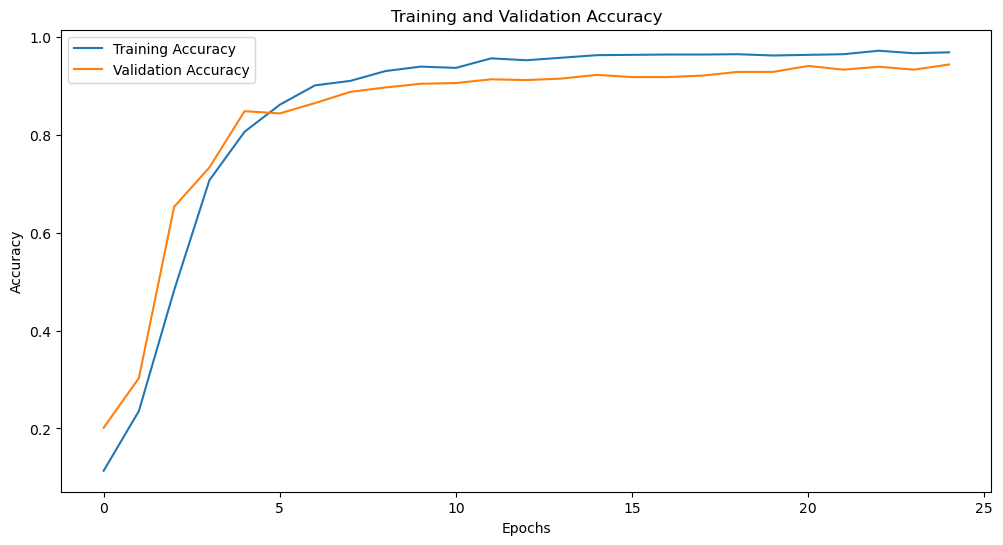

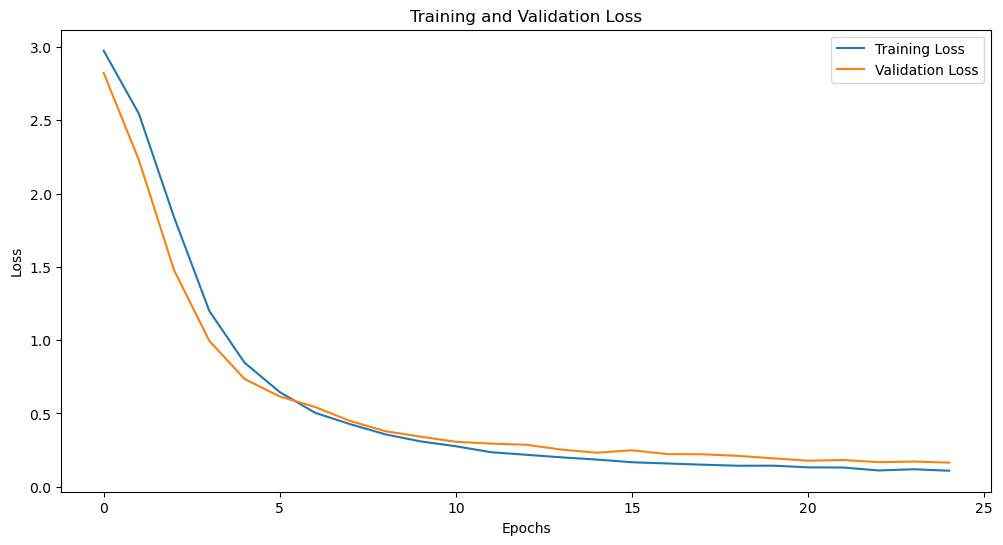

In [45]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [49]:
# 7. Model Deployment
# Save the scaler and the model
joblib.dump(scaler, 'App/crop_recommendation_scaler.joblib')
model.save('App/crop_recommendation_model.keras')
model.save('App/crop_recommendation_model.h5')

In [ ]:
# 8. Model Monitoring and Maintenance
# (Future Work: Track model performance over time, retrain with new data if required)